In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm


In [128]:
df=pd.read_csv(r"C:\Users\vaish\OneDrive\Desktop\MSc\Python\flights_final.csv")

In [129]:
df=pd.DataFrame(df)

In [130]:
df.head()

,dep_time,sched_dep_time,arr_time,sched_arr_time,carrier,flight,tailnum,origin,dest,air_time,distance,time_hour
0,1.0,2038,328.0,3,UA,628,N25201,EWR,SMF,367.0,2500,01-01-2023 20:00
1,18.0,2300,228.0,135,DL,393,N830DN,JFK,ATL,108.0,760,01-01-2023 23:00
2,31.0,2344,500.0,426,B6,371,N807JB,JFK,BQN,190.0,1576,01-01-2023 23:00
3,33.0,2140,238.0,2352,B6,1053,N265JB,JFK,CHS,108.0,636,01-01-2023 21:00
4,36.0,2048,223.0,2252,UA,219,N17730,EWR,DTW,80.0,488,01-01-2023 20:00


In [131]:
df.describe()

,dep_time,sched_dep_time,arr_time,sched_arr_time,flight,air_time,distance
count,425478.000000,436228.000000,424759.000000,436228.000000,436228.000000,423676.000000,436228.000000
mean,1365.713976,1363.654694,1496.522247,1551.580781,785.116396,141.812720,977.452864
std,498.061616,478.291841,550.519263,513.312616,497.429573,89.173923,702.886617
min,1.000000,500.000000,1.000000,1.000000,1.000000,18.000000,80.000000
25%,931.000000,930.000000,1105.000000,1135.000000,364.000000,77.000000,479.000000
50%,1357.000000,1359.000000,1519.000000,1551.000000,734.000000,120.000000,762.000000
75%,1804.000000,1759.000000,1946.000000,2007.000000,1188.000000,177.000000,1182.000000
max,2400.000000,2359.000000,2400.000000,2359.000000,1972.000000,701.000000,4983.000000


In [132]:
print("Shape before cleaning:", df.shape)

Shape before cleaning: (436228, 12)


##### Our dataset has 436228 rows and 12 columns 

In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 436228 entries, 0 to 436227
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   dep_time        425478 non-null  float64
 1   sched_dep_time  436228 non-null  int64  
 2   arr_time        424759 non-null  float64
 3   sched_arr_time  436228 non-null  int64  
 4   carrier         436228 non-null  object 
 5   flight          436228 non-null  int64  
 6   tailnum         434313 non-null  object 
 7   origin          436228 non-null  object 
 8   dest            436228 non-null  object 
 9   air_time        423676 non-null  float64
 10  distance        436228 non-null  int64  
 11  time_hour       436228 non-null  object 
dtypes: float64(3), int64(4), object(5)
memory usage: 39.9+ MB


##### All variables seem to have the correct data type except time_hour which is of object type  

In [135]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 876


##### Data has 876 duplicates which needs to be removed 

In [136]:
print("\nMissing values before cleaning:\n", df.isnull().sum())


Missing values before cleaning:
 dep_time          10750
sched_dep_time        0
arr_time          11469
sched_arr_time        0
carrier               0
flight                0
tailnum            1915
origin                0
dest                  0
air_time          12552
distance              0
time_hour             0
dtype: int64


##### dep_time, arr_time, tailnum, air_time has missing values which needs to be handled

#### 1. Data Cleaning

##### 1.1 Removing Duplicates

In [137]:
df = df.drop_duplicates()

In [138]:
print("Number of duplicate rows after cleaning:", df.duplicated().sum())

Number of duplicate rows after cleaning: 0


##### 1.2 Handling Incorrect datatype

In [139]:
df['time_hour']=pd.to_datetime(df['time_hour'],errors='coerce')

##### 1.3 Handling missing values 

In [140]:
print("The mean departure time is:",df['dep_time'].mean())
print("The median departure time is:",df['dep_time'].median())

The mean departure time is: 1365.6987381480592
The median departure time is: 1357.0


In [141]:
print("The mean arrival time is:",df['arr_time'].mean())
print("The median arrival time is:",df['arr_time'].median())

The mean arrival time is: 1496.5092038433684
The median arrival time is: 1519.0


In [142]:
print("The mean air time is:",df['air_time'].mean())
print("The median air time is:",df['air_time'].median())

The mean air time is: 141.82025836175376
The median air time is: 121.0


##### The mean and median of the three numerical variables does not show a significant difference so we can replace it with either mean or median

In [143]:
print("Value counts in City column: \n",df['tailnum'].value_counts())

Value counts in City column: 
 N490PX    736
N480PX    718
N491PX    706
N915XJ    688
N479PX    684
         ... 
N269NN      1
N2157J      1
N298FR      1
252NV       1
N321DU      1
Name: tailnum, Length: 5117, dtype: int64


##### Since tailnum variable is of object type we can replace it with mode

In [144]:
for col in ["dep_time", "arr_time", "air_time"]:
    df[col].fillna(df[col].median(), inplace=True)

In [145]:
df["tailnum"].fillna(df["tailnum"].mode()[0], inplace=True)

#### After cleaning

In [146]:
print("Shape after cleaning:", df.shape)

Shape after cleaning: (435352, 12)


In [147]:
print("\nMissing values after cleaning:\n", df.isnull().sum())


Missing values after cleaning:
 dep_time          0
sched_dep_time    0
arr_time          0
sched_arr_time    0
carrier           0
flight            0
tailnum           0
origin            0
dest              0
air_time          0
distance          0
time_hour         0
dtype: int64


In [148]:
print("\nData types afte cleaning:\n", df.dtypes)


Data types afte cleaning:
 dep_time                 float64
sched_dep_time             int64
arr_time                 float64
sched_arr_time             int64
carrier                   object
flight                     int64
tailnum                   object
origin                    object
dest                      object
air_time                 float64
distance                   int64
time_hour         datetime64[ns]
dtype: object


#### 1.4. Feature engineering

 We aim to create the following features 
 1. year
 2. month
 3. day
 3. hour
 4. minute
 5. departure delay
 6. arrival delay
 7. route
 8. delay category
 9. time slot
 10. day of the week

In [149]:
# Extract date and time components
df['year'] = df['time_hour'].dt.year
df['month'] = df['time_hour'].dt.month
df['day'] = df['time_hour'].dt.day
df['hour'] = df['time_hour'].dt.hour
df['minute'] = df['time_hour'].dt.minute
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])  
df['day_of_week'] = df['date'].dt.day_name()


In [150]:
#creating time slots

# Extract hour from departure time
df['dep_hour'] = df['dep_time'] // 100   # if dep_time is like 1345 → 13

# Define slots
conditions = [
    (df['dep_hour'] >= 5) & (df['dep_hour'] < 12),
    (df['dep_hour'] >= 12) & (df['dep_hour'] < 17),
    (df['dep_hour'] >= 17) & (df['dep_hour'] < 21),
    (df['dep_hour'] >= 21) | (df['dep_hour'] < 5)
]

labels = ['Morning (5–11am)', 'Afternoon (12–4pm)', 
          'Evening (5–8pm)', 'Night (9pm–4am)']

df['time_slot'] = np.select(conditions, labels)


In [151]:
df[['time_hour','year','month','day','hour','minute','date','day_of_week','time_slot']].head()


,time_hour,year,month,day,hour,minute,date,day_of_week,time_slot
0,2023-01-01 20:00:00,2023,1,1,20,0,2023-01-01,Sunday,Night (9pm–4am)
1,2023-01-01 23:00:00,2023,1,1,23,0,2023-01-01,Sunday,Night (9pm–4am)
2,2023-01-01 23:00:00,2023,1,1,23,0,2023-01-01,Sunday,Night (9pm–4am)
3,2023-01-01 21:00:00,2023,1,1,21,0,2023-01-01,Sunday,Night (9pm–4am)
4,2023-01-01 20:00:00,2023,1,1,20,0,2023-01-01,Sunday,Night (9pm–4am)


In [152]:
#Creating route
# Combine origin and destination into route
df["route"] = df["origin"] + "-" + df["dest"]
df['route'].head()

0    EWR-SMF
1    JFK-ATL
2    JFK-BQN
3    JFK-CHS
4    EWR-DTW
Name: route, dtype: object

In [153]:
def to_minutes(x):
    x = np.asarray(x, dtype=int)  # ensures NumPy array and makes this faster
    return (x // 100) * 60 + (x % 100)

Flight times are usually stored as HHMM format integers (e.g., 930 = 9:30 AM, 1435 = 2:35 PM).

This function converts that into minutes since midnight.

Example:

930 → (9 * 60) + 30 = 570 minutes

1435 → (14 * 60) + 35 = 875 minutes

In [154]:
# calculate arrival delay
df['arr_delay'] = to_minutes(df['arr_time']) - to_minutes(df['sched_arr_time'])

# Fix only true overnight flights (big negative values)
df.loc[df['arr_delay'] < -1000, 'arr_delay'] += 1440


##### Fixing overnight flights logic

If a flight departs late at night and arrives after midnight, the raw subtraction may give a large negative number (since next-day arrivals wrap around midnight).

1440 = 24 hours * 60 minutes.

So if the delay looks unrealistically negative (< -1000 minutes), it adds 1440 to shift it into the correct positive delay range.

Example:

Scheduled: 23:55 (1435 min),

Actual: 00:10 (10 min),

Raw delay = 10 – 1435 = -1425 → fixed to -1425 + 1440 = 15 min.

In [155]:
df['arr_delay'].head()

0    205
1     53
2     34
3    166
4    211
Name: arr_delay, dtype: int32

In [156]:
#Calculate departure delay
df['dep_delay'] = to_minutes(df['dep_time']) - to_minutes(df['sched_dep_time'])
df.loc[df['dep_delay'] < -1000, 'dep_delay'] += 1440

In [157]:
df['dep_delay'].head()

0    203
1     78
2     47
3    173
4    228
Name: dep_delay, dtype: int32

#### Computing delay categories

In [158]:
# Define conditions
conditions = [
    (df['arr_delay'] <= 0),
    (df['arr_delay'] > 0) & (df['arr_delay'] <= 15),
    (df['arr_delay'] > 15) & (df['arr_delay'] <= 60),
    (df['arr_delay'] > 60) & (df['arr_delay'] <= 180),
    (df['arr_delay'] > 180)
]

# Define category labels

categories = ['On Time/Early', 'Slight Delay', 'Moderate Delay', 'Long Delay', 'Very Long Delay']

# Apply
df['arr_delay_category'] = np.select(conditions, categories)

In [159]:
df['arr_delay_category'].head()

0    Very Long Delay
1     Moderate Delay
2     Moderate Delay
3         Long Delay
4    Very Long Delay
Name: arr_delay_category, dtype: object

In [160]:
# Define conditions
conditions = [
    (df['dep_delay'] <= 0),
    (df['dep_delay'] > 0) & (df['dep_delay'] <= 15),
    (df['dep_delay'] > 15) & (df['dep_delay'] <= 60),
    (df['dep_delay'] > 60) & (df['dep_delay'] <= 180),
    (df['dep_delay'] > 180)
]

# Define category labels

categories = ['On Time/Early', 'Slight Delay', 'Moderate Delay', 'Long Delay', 'Very Long Delay']

# Apply
df['dep_delay_category'] = np.select(conditions, categories)

In [161]:
df['dep_delay_category'].head()

0    Very Long Delay
1         Long Delay
2     Moderate Delay
3         Long Delay
4    Very Long Delay
Name: dep_delay_category, dtype: object

#### 2. Descriptive Statistics

##### Dealy Analysis

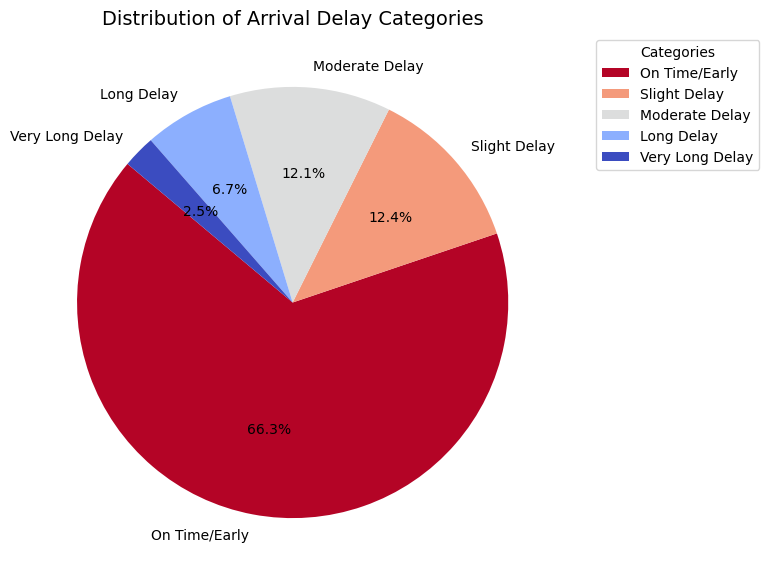

In [195]:
# Pie chart for Arrival Delay Categories

arr_counts = df['arr_delay_category'].value_counts()

colors = cm.coolwarm_r(np.linspace(0, 1, len(arr_counts)))

plt.figure(figsize=(7,7))
plt.pie(
    arr_counts,
    labels=arr_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors
)

plt.title('Distribution of Arrival Delay Categories', fontsize=14)
plt.legend(arr_counts.index, title="Categories", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


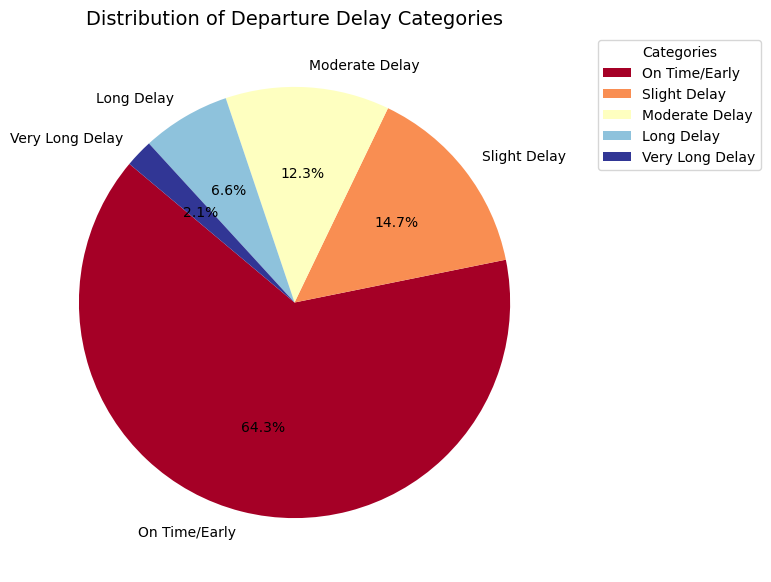

In [199]:
# Pie chart for Departure Delay Categories

dep_counts = df['dep_delay_category'].value_counts()

colors = cm.RdYlBu(np.linspace(0, 1, len(dep_counts)))

plt.figure(figsize=(7,7))
plt.pie(
    dep_counts,
    labels=dep_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors
)

plt.title('Distribution of Departure Delay Categories', fontsize=14)
plt.legend(dep_counts.index, title="Categories", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


In [164]:
print("="*40)
print(" 📊 Arrival Delay Statistics ")
print("="*40)
print(f"Average Delay : {df['arr_delay'].mean():.2f} minutes")
print(f"Median Delay  : {df['arr_delay'].median():.2f} minutes")
print(f"Minimum Delay : {df['arr_delay'].min()} minutes")
print(f"Maximum Delay : {df['arr_delay'].max()} minutes")
print("="*40)


 📊 Arrival Delay Statistics 
Average Delay : 3.81 minutes
Median Delay  : -10.00 minutes
Minimum Delay : -1000 minutes
Maximum Delay : 1439 minutes


In [165]:
print("="*40)
print(" 📊 Departure Delay Statistics ")
print("="*40)
print(f"Average Delay : {df['dep_delay'].mean():.2f} minutes")
print(f"Median Delay  : {df['dep_delay'].median():.2f} minutes")
print(f"Minimum Delay : {df['dep_delay'].min()} minutes")
print(f"Maximum Delay : {df['dep_delay'].max()} minutes")
print("="*40)


 📊 Departure Delay Statistics 
Average Delay : 8.88 minutes
Median Delay  : -3.00 minutes
Minimum Delay : -1000 minutes
Maximum Delay : 1057 minutes


###  Route wise summary using pandas

##### We are gonna consider arrival delay going forward since it's widely regarded as net delay in airline services

#### Best and worst 5 routes

In [166]:
# Average delays per route
route_delay_summary = df.groupby(['route']).agg(
    avg_arr_delay=('arr_delay', 'mean'),
    total_flights=('arr_delay', 'size'),
    delayed_arrivals=('arr_delay', lambda x: (x > 0).sum()),
).reset_index()

# Calculate percentages
route_delay_summary['perc_delayed_arrivals'] = (
    route_delay_summary['delayed_arrivals'] / route_delay_summary['total_flights'] * 100
)

# Round numeric values
route_delay_summary['avg_arr_delay'] = route_delay_summary['avg_arr_delay'].round(2)

# Format percentage with 2 decimals + %
route_delay_summary['perc_delayed_arrivals'] = (
    route_delay_summary['perc_delayed_arrivals'].round(1).astype(str) + '%'
)


In [167]:
top5 = route_delay_summary.sort_values(
    by='avg_arr_delay', ascending=False
).head(5)

print("Worst 5 Routes by Average Arrival Delay:")
(top5[['route', 'avg_arr_delay', 'perc_delayed_arrivals', 'total_flights']])


Worst 5 Routes by Average Arrival Delay:


,route,avg_arr_delay,perc_delayed_arrivals,total_flights
96,JFK-BGR,147.56,42.6%,516
161,JFK-SYR,127.64,45.3%,1564
142,JFK-PWM,115.64,40.2%,1208
148,JFK-SAN,74.19,40.8%,2500
140,JFK-PSE,64.27,66.4%,333


In [168]:
top5 = route_delay_summary.sort_values(
    by='avg_arr_delay', ascending=True
).head(5)

print("Best 5 Routes by Average Arrival Delay:")
(top5[['route', 'avg_arr_delay', 'perc_delayed_arrivals', 'total_flights']])


Best 5 Routes by Average Arrival Delay:


,route,avg_arr_delay,perc_delayed_arrivals,total_flights
35,EWR-ILM,-31.78,23.6%,589
76,EWR-SCE,-29.00,0.0%,1
7,EWR-BGR,-27.29,29.0%,668
44,EWR-MDT,-26.06,29.8%,510
5,EWR-AVL,-21.90,19.9%,589


#### Consistency of Routes

A route is “consistent” if delays don’t fluctuate wildly.
We measure this using standard deviation (σ) or coefficient of variation (CV = σ/mean) of delays per route.

In [169]:
# Consistency of routes (low std dev means consistent)
route_consistency = (
    df.groupby("route")
    .agg(
        avg_arr_delay=("arr_delay", "mean"),
        std_arr_delay=("arr_delay", "std"),
        cv_arr_delay=("arr_delay", lambda x: x.std()/x.mean() if x.mean()!=0 else None),
        total_flights=("arr_delay", "size")
    )
    .reset_index()
    .sort_values(by="std_arr_delay")
)

print("Most Consistent Routes (lowest variation in arrival delays):")
(route_consistency.head(5))


Most Consistent Routes (lowest variation in arrival delays):


,route,avg_arr_delay,std_arr_delay,cv_arr_delay,total_flights
37,EWR-ITH,-16.846154,10.015373,-0.594520,13
64,EWR-PSP,-9.500000,16.583124,-1.745592,4
75,EWR-SBN,2.600000,18.756332,7.213974,5
90,EWR-TYS,-11.403101,21.070388,-1.847777,129
0,EWR-ABQ,-5.363636,21.402209,-3.990242,11


In [170]:
print("\nLeast Consistent Routes (highest variation in arrival delays):")
(route_consistency.tail(5))


Least Consistent Routes (highest variation in arrival delays):


,route,avg_arr_delay,std_arr_delay,cv_arr_delay,total_flights
142,JFK-PWM,115.635762,389.973262,3.372428,1208
161,JFK-SYR,127.640665,400.699543,3.139278,1564
96,JFK-BGR,147.556202,444.339360,3.011323,516
76,EWR-SCE,-29.000000,NaN,NaN,1
207,LGA-LEX,7.000000,NaN,NaN,1


#####  Route Congestion Factor

 Congestion = how crowded a route is relative to all others.
 
We define congestion factor = flights on route ÷ total flights.

Can also see if congestion correlates with delays.

In [171]:
total_flights = len(df)

route_congestion = (
    df.groupby("route")
    .agg(
        total_flights=("route", "size"),
        avg_arr_delay=("arr_delay", "mean"),
        avg_dep_delay=("dep_delay", "mean")
    )
    .reset_index()
)

# Add congestion factor
route_congestion["congestion_factor"] = route_congestion["total_flights"] / total_flights

# See if high congestion = high delays
route_congestion = route_congestion.sort_values(by="congestion_factor", ascending=False)

print("Route Congestion Factors:")
(route_congestion.head(5))


Route Congestion Factors:


,route,total_flights,avg_arr_delay,avg_dep_delay,congestion_factor
124,JFK-LAX,10045,19.476257,10.037432,0.023073
223,LGA-ORD,9923,0.189157,10.731533,0.022793
173,LGA-BOS,8217,-1.333333,7.973470,0.018874
166,LGA-ATL,7883,1.494228,11.990993,0.018107
153,JFK-SFO,7440,12.434140,8.519220,0.017090


##### Route Reliability Index

 A “score” that combines frequency of delays + severity of delays.

In [172]:
def reliability_index(x):
    perc_delayed = (x > 0).mean()
    avg_delay_if_delayed = x[x > 0].mean() if (x > 0).any() else 0
    return (1 - perc_delayed) * (1 / (1 + (avg_delay_if_delayed if avg_delay_if_delayed else 0)))

route_reliability = (
    df.groupby("route")["arr_delay"]
    .apply(reliability_index)
    .reset_index(name="reliability_index")
    .sort_values(by="reliability_index", ascending=False)
)

print("Most Reliable Routes:")
(route_reliability.head(5))


Most Reliable Routes:


,route,reliability_index
76,EWR-SCE,1.000000
37,EWR-ITH,0.461538
64,EWR-PSP,0.075000
230,LGA-PNS,0.036319
90,EWR-TYS,0.034958


In [173]:

print("\nLeast Reliable Routes:")
(route_reliability.tail(5))



Least Reliable Routes:


,route,reliability_index
148,JFK-SAN,0.002591
142,JFK-PWM,0.001812
161,JFK-SYR,0.001720
96,JFK-BGR,0.001504
207,LGA-LEX,0.000000


####  Weekly delay analysis using pivot table

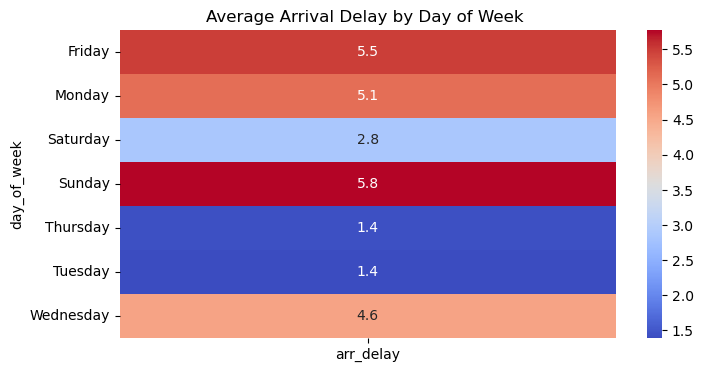

In [174]:
# 1. Average delay per day of the week
pivot_day = pd.pivot_table(df, values='arr_delay', index='day_of_week', aggfunc='mean')
plt.figure(figsize=(8,4))
sns.heatmap(pivot_day, annot=True, fmt=".1f", cmap="coolwarm", cbar=True)
plt.title("Average Arrival Delay by Day of Week ")
plt.show()

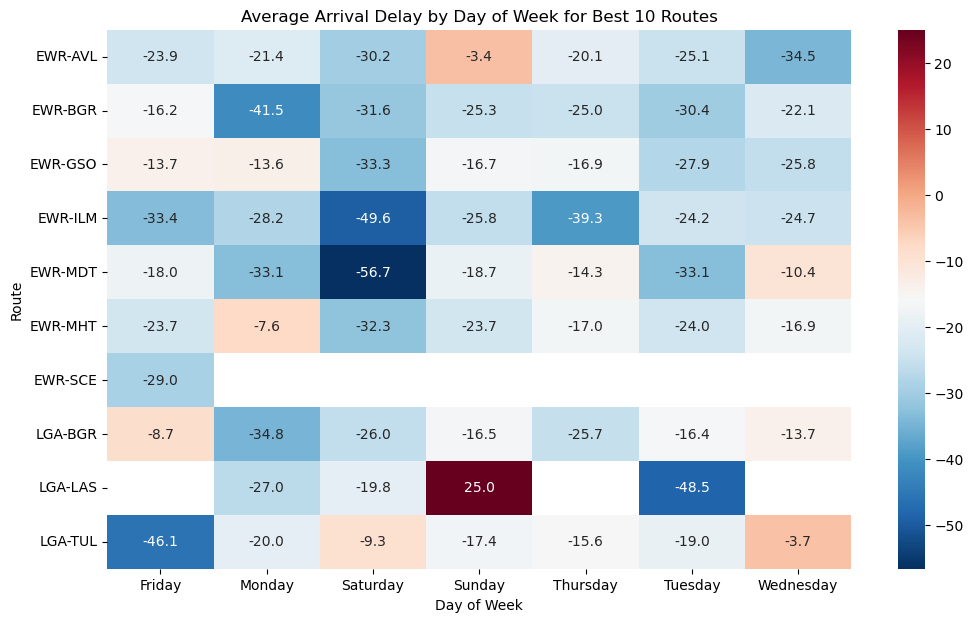

In [184]:
#2. Route vs Day

# Average delay by route
avg_delay_by_route = df.groupby('route')['arr_delay'].mean().sort_values(ascending=True).head(10).index

# Heatmap only for worst 15 routes
pivot_route_day = pd.pivot_table(
    df[df['route'].isin(avg_delay_by_route)],
    values='arr_delay',
    index='route',
    columns='day_of_week',
    aggfunc='mean'
)

plt.figure(figsize=(12,7))
sns.heatmap(pivot_route_day, annot=True, fmt=".1f", cmap="RdBu_r", cbar=True)
plt.title("Average Arrival Delay by Day of Week for Best 10 Routes")
plt.xlabel("Day of Week")
plt.ylabel("Route")
plt.show()


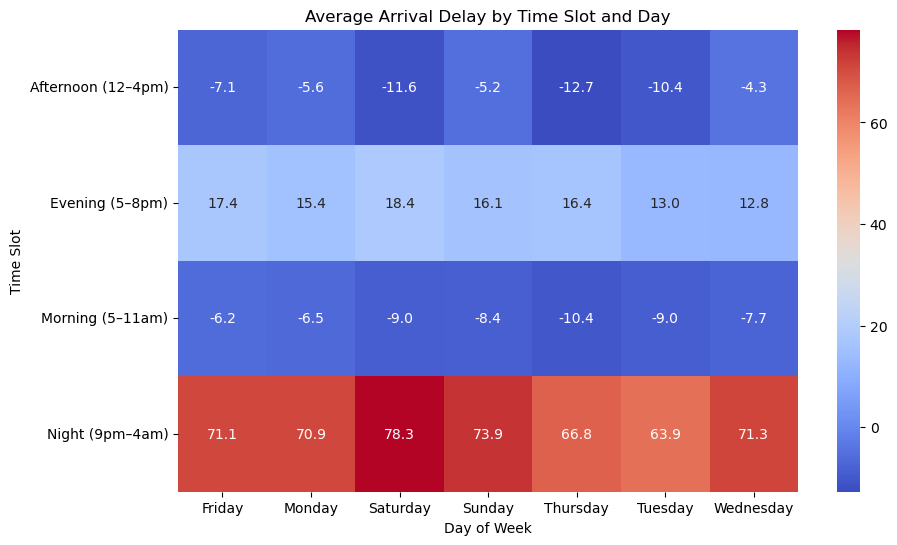

In [176]:
# 3. Time Slot vs Day
pivot_time_day = pd.pivot_table(df, values='arr_delay', index='time_slot', columns='day_of_week', aggfunc='mean')
plt.figure(figsize=(10,6))
sns.heatmap(pivot_time_day, annot=True, fmt=".1f", cmap="coolwarm", cbar=True)
plt.title("Average Arrival Delay by Time Slot and Day")
plt.xlabel("Day of Week")
plt.ylabel("Time Slot")
plt.show()

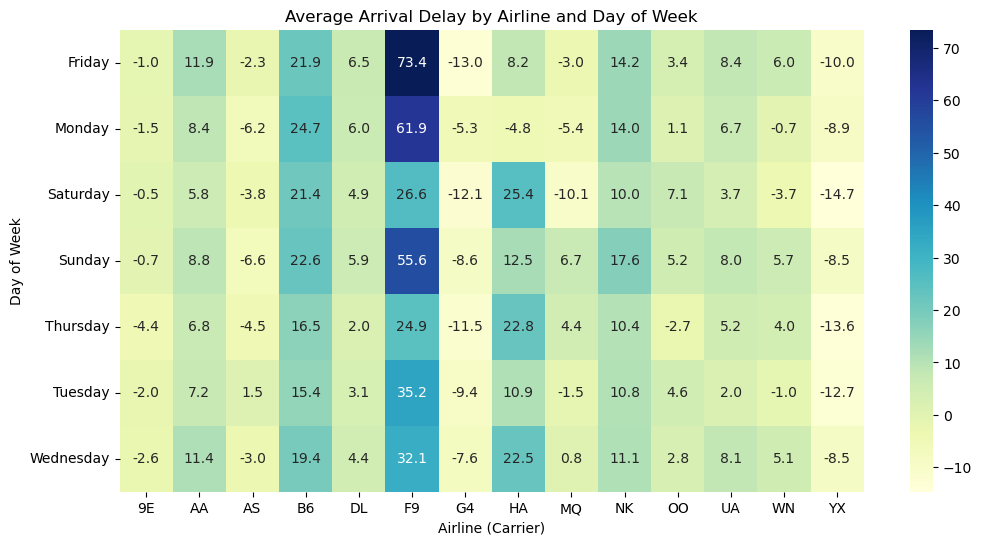

In [177]:
#4. Average Arrival Delay by Airline and Day of Week

pivot_airline_day = pd.pivot_table(
    df,
    values='arr_delay',
    index='day_of_week',
    columns='carrier',
    aggfunc='mean'
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot_airline_day, annot=True, fmt=".1f", cmap="YlGnBu", cbar=True)
plt.title("Average Arrival Delay by Airline and Day of Week")
plt.xlabel("Airline (Carrier)")
plt.ylabel("Day of Week")
plt.show()


In [201]:
#5. Departure vs Arrival Delay by Weekday

pivot_dep_arr = pd.pivot_table(
    df,
    values=['dep_delay','arr_delay'],
    index='day_of_week',
    aggfunc='mean'
)

print(pivot_dep_arr)


             arr_delay  dep_delay
day_of_week                      
Friday        5.485076  10.189479
Monday        5.104865   9.412314
Saturday      2.848019   8.112967
Sunday        5.773846  10.456313
Thursday      1.429261   7.478182
Tuesday       1.388548   6.475355
Wednesday     4.566047   9.959607


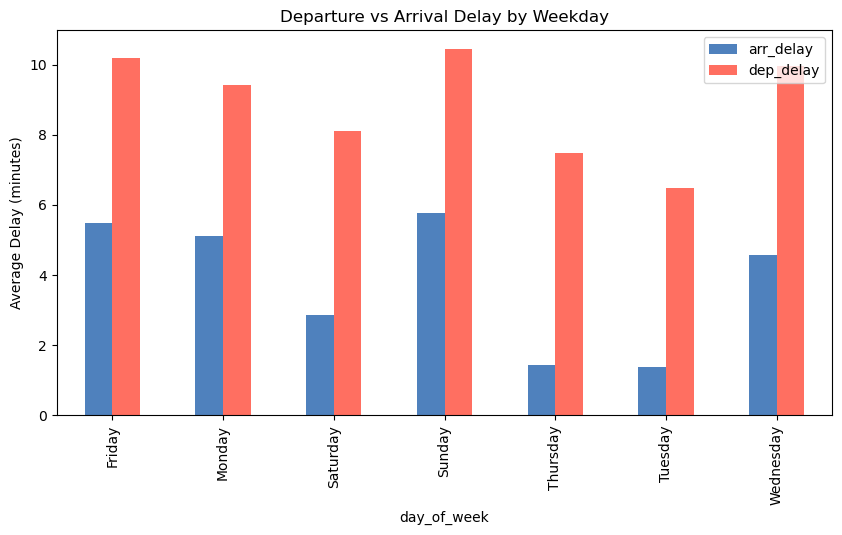

In [207]:
colors = ["#4F81BD", "#FF6F61"]   # blue + pink
pivot_dep_arr.plot(kind='bar', figsize=(10,5),color=colors)
plt.title("Departure vs Arrival Delay by Weekday")
plt.ylabel("Average Delay (minutes)")
plt.show()


####  Delay patterns using line graphs 

C:\Users\vaish\AppData\Local\Temp\ipykernel_5896\2955852443.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x='hour', y='arr_delay', hue='day_of_week', ci=None, style='day_of_week',


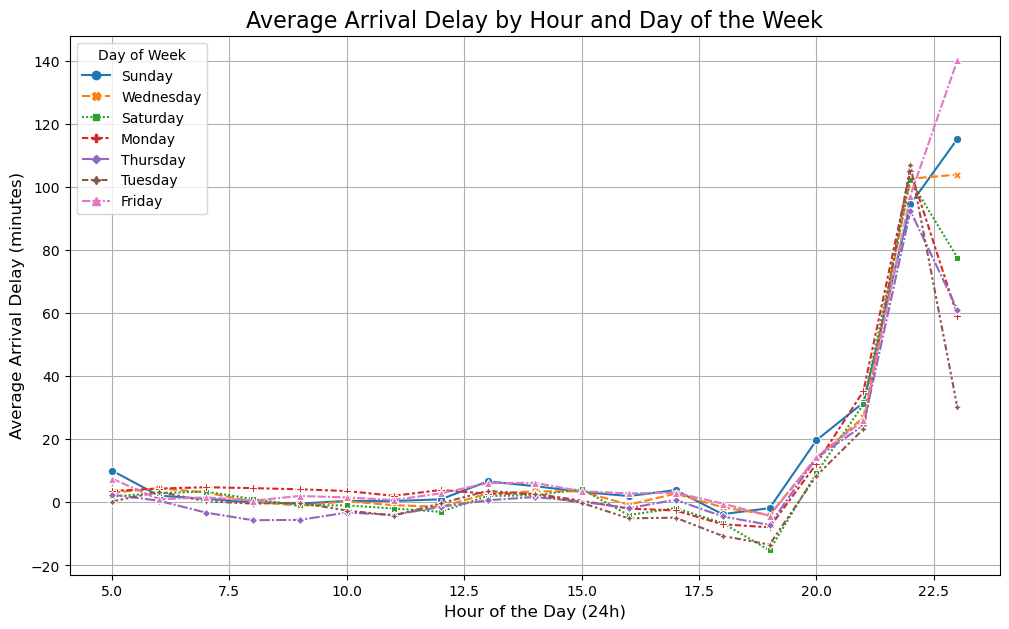

In [107]:
# 1. Hourly Delay Trends by Day of the Week
plt.figure(figsize=(12, 7))
sns.lineplot(data=df, x='hour', y='arr_delay', hue='day_of_week', ci=None, style='day_of_week',
             markers=True)
plt.title('Average Arrival Delay by Hour and Day of the Week', fontsize=16)
plt.xlabel('Hour of the Day (24h)', fontsize=12)
plt.ylabel('Average Arrival Delay (minutes)', fontsize=12)
plt.grid(True)
plt.legend(title='Day of Week')
plt.show()

The graph "Average Arrival Delay by Hour and Day of the Week" reveals how delays fluctuate throughout the day, broken down by day of the week.

Delays are relatively stable and low during the daytime hours, from approximately 5 AM to 8 PM, typically staying within a range of about -10 to +10 minutes.

There's a dramatic and sharp increase in delays for all days of the week starting around 9 PM (hour 21). This pattern indicates that late-night flights are significantly more prone to long delays than earlier flights.

Friday and Sunday appear to have the most severe late-night delays, with average delays exceeding 100 minutes at some points. This suggests that weekend travel and the end-of-the-work-week rush contribute to major operational bottlenecks.

C:\Users\vaish\AppData\Local\Temp\ipykernel_5896\3730601743.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_top_carriers, x='month', y='arr_delay', hue='carrier', ci=None, style='carrier', markers=True)


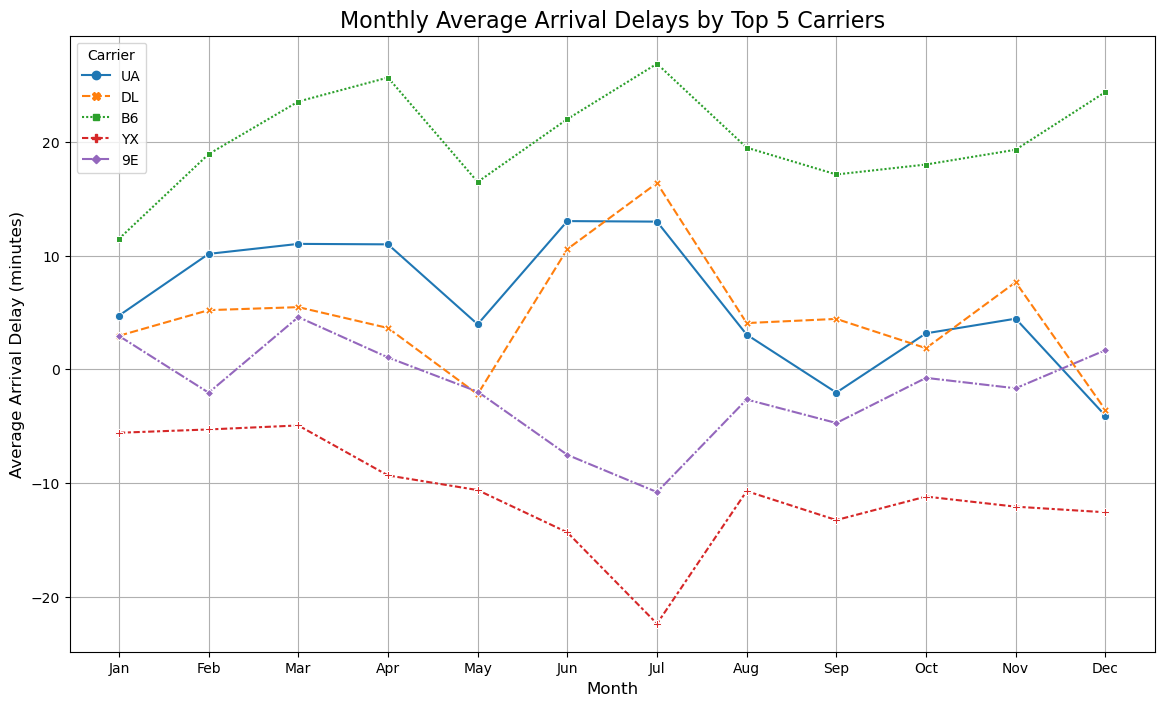

In [108]:
# 2. Monthly Average Delays Over the Year, Grouped by Carrier
plt.figure(figsize=(14, 8))
# Filter for top carriers to avoid a messy plot
top_carriers = df['carrier'].value_counts().nlargest(5).index
df_top_carriers = df[df['carrier'].isin(top_carriers)]
sns.lineplot(data=df_top_carriers, x='month', y='arr_delay', hue='carrier', ci=None, style='carrier', markers=True)
plt.title('Monthly Average Arrival Delays by Top 5 Carriers', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Arrival Delay (minutes)', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.legend(title='Carrier')
plt.show()

The graph "Monthly Average Arrival Delays by Top 5 Carriers" shows how the average arrival delay for the five most frequent carriers changes over the year.

B6 (JetBlue) consistently has the highest average delays, particularly spiking from June to August, with a peak in July.

DL (Delta) and UA (United) show similar delay patterns, with delays increasing during the summer months and then declining.

YX and 9E generally have negative average delays, meaning they tend to arrive early on average. This early arrival is especially pronounced for YX in July, where its average is more than 20 minutes early.

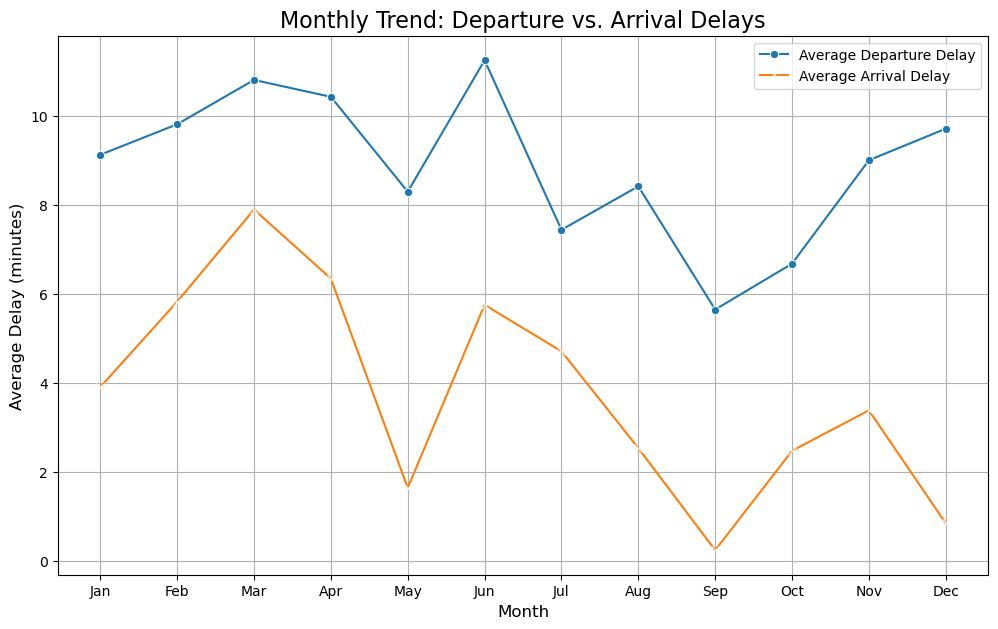

In [113]:
#3. Monthly Departure vs. Arrival Delay Trend
monthly_delays = df.groupby('month')[['dep_delay', 'arr_delay']].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.lineplot(data=monthly_delays, x='month', y='dep_delay', label='Average Departure Delay', marker='o')
sns.lineplot(data=monthly_delays, x='month', y='arr_delay', label='Average Arrival Delay', marker='x')

plt.title('Monthly Trend: Departure vs. Arrival Delays', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Delay (minutes)', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.legend()
plt.show()



The graph "Monthly Trend: Departure vs. Arrival Delays" compares the average departure delay and average arrival delay month by month.

Average departure delays are consistently higher than average arrival delays throughout the year. This suggests that airlines are successful in making up time in the air.

Both departure and arrival delays follow a similar seasonal pattern, with delays generally increasing from the beginning of the year and peaking in June. This indicates that summer months are the most challenging for on-time performance.

There's a significant drop in both delay types in September, followed by another rise in October and November before a slight decrease in December.

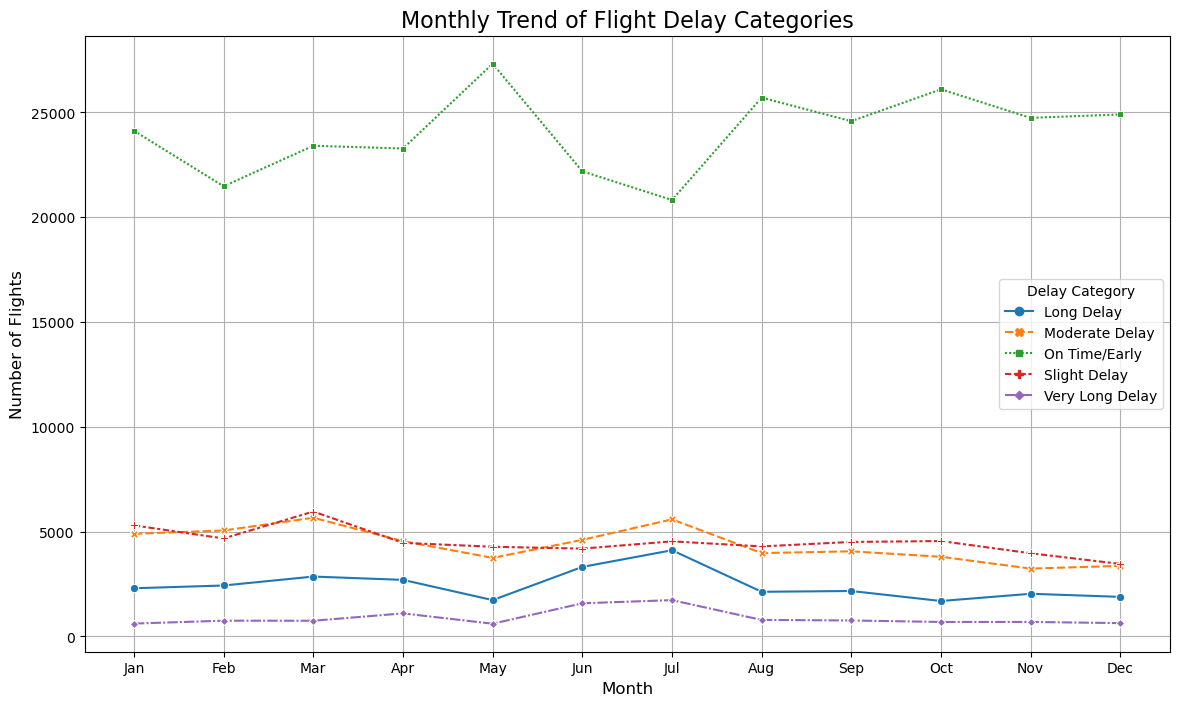

In [116]:
# 4.Monthly Delays by Delay Category
# Group by month and delay category, then count the number of flights
monthly_category_counts = df.groupby(['month', 'arr_delay_category']).size().reset_index(name='count')

plt.figure(figsize=(14, 8))
sns.lineplot(data=monthly_category_counts, x='month', y='count', hue='arr_delay_category', style='arr_delay_category', markers=True)

plt.title('Monthly Trend of Flight Delay Categories', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Flights', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.legend(title='Delay Category')
plt.show()

The graph "Monthly Trend of Flight Delay Categories" shows the number of flights that fall into different delay categories each month.

The "On Time/Early" category (green dotted line) has the highest number of flights, and it shows a clear seasonal pattern, with fewer on-time flights in the summer months of June and July. This aligns with the previous findings of higher average delays in the summer.

The number of flights in the "Moderate Delay" category (orange dashed line) and "Slight Delay" category (red dashed line) are relatively consistent throughout the year, with a minor increase during the peak summer months.

The number of "Long Delay" flights (blue solid line) and "Very Long Delay" flights (purple dot-dash line) are the lowest but also show a notable increase in the summer, especially in June and July, confirming that the peak travel season leads to more severe delays.

####  Route wise performance using bar charts 

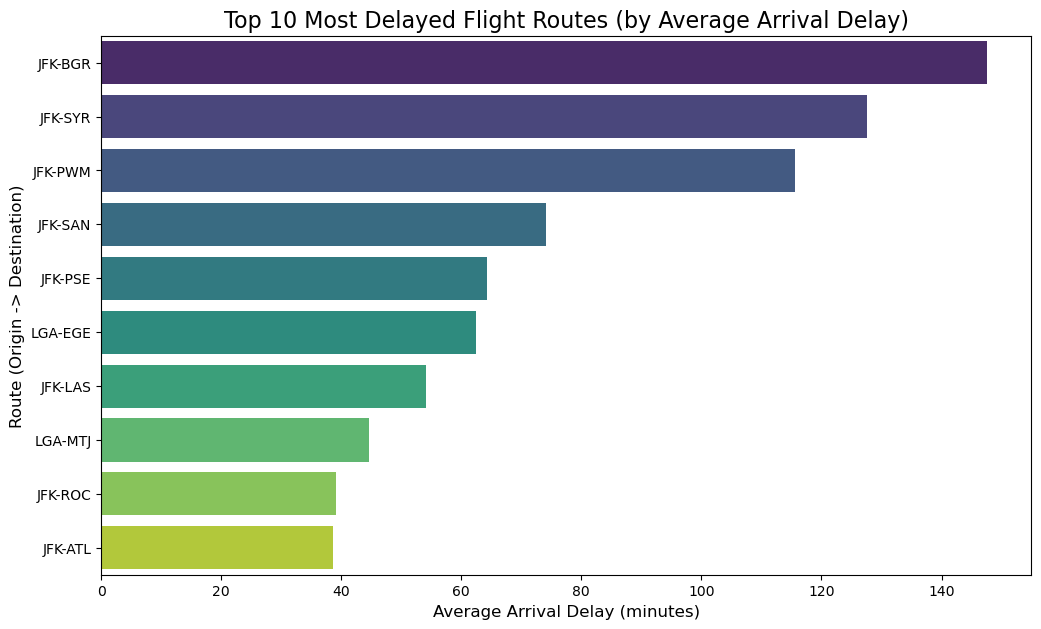

In [109]:
# 1. Top 10 Most Delayed Routes
route_delays = df.groupby('route')['arr_delay'].mean().nlargest(10).reset_index()
plt.figure(figsize=(12, 7))
sns.barplot(data=route_delays, x='arr_delay', y='route', palette='viridis')
plt.title('Top 10 Most Delayed Flight Routes (by Average Arrival Delay)', fontsize=16)
plt.xlabel('Average Arrival Delay (minutes)', fontsize=12)
plt.ylabel('Route (Origin -> Destination)', fontsize=12)
plt.show()

This bar chart, "Top 10 Most Delayed Flight Routes (by Average Arrival Delay)," shows the average arrival delay in minutes for the ten routes with the highest delays.

The route from JFK to BGR (Bangor, Maine) is by far the most delayed, with an average arrival delay of over 140 minutes.

JFK-SYR and JFK-PWM also experience significantly high average delays, both exceeding 100 minutes.

Routes with origins at LGA and destinations like EGE and MTJ have lower average delays compared to the top three, indicating better performance on those routes.

The general trend is a decrease in average delay from the top to the bottom of the list, with the bottom two routes, JFK-ROC and JFK-ATL, having average delays below 50 minutes.

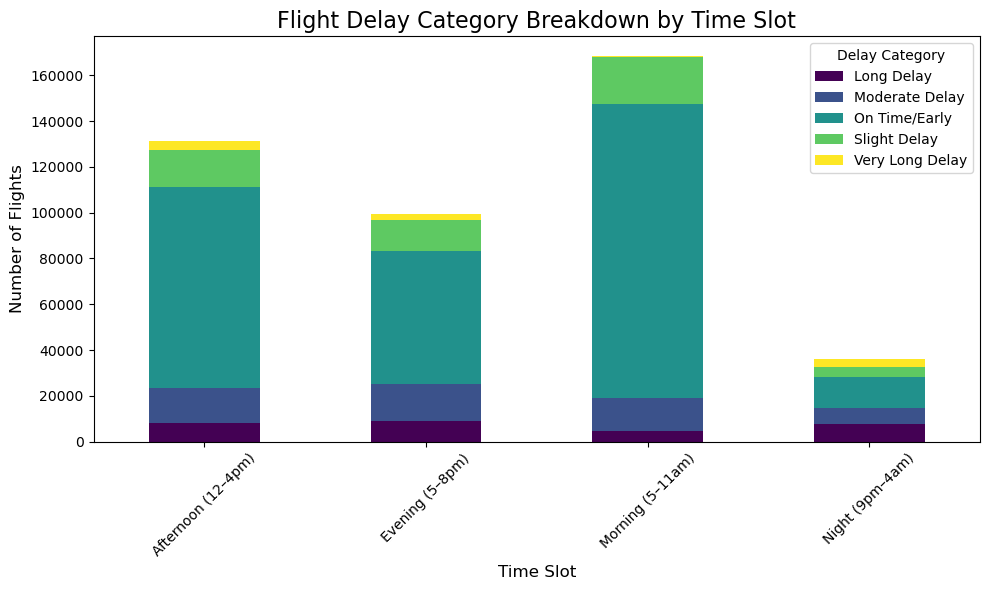

In [112]:
# 2. Delay Category Breakdown by Time Slot (Stacked Bar Chart)
delay_counts = df.groupby(['time_slot', 'arr_delay_category']).size().unstack(fill_value=0)

delay_counts.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Flight Delay Category Breakdown by Time Slot', fontsize=16)
plt.xlabel('Time Slot', fontsize=12)
plt.ylabel('Number of Flights', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Delay Category')
plt.tight_layout()
plt.show()

This  chart shows the total number of flights in each delay category across different time slots.

The Morning (5-11 am) time slot has the highest number of flights overall and the largest proportion of 'On Time/Early' flights (light green segment), reinforcing the idea that morning is the most reliable time to fly.

The Night (9 pm-4 am) time slot has the fewest flights overall, but a significant proportion of these flights fall into the 'Long Delay' (dark blue) and 'Very Long Delay' (yellow) categories. This confirms that while late-night flights are less common, they have a higher risk of severe delays.

The Afternoon (12-4 pm) and Evening (5-8 pm) time slots have a large number of flights and a similar distribution of delay categories, with a healthy mix of on-time and slightly delayed flights.

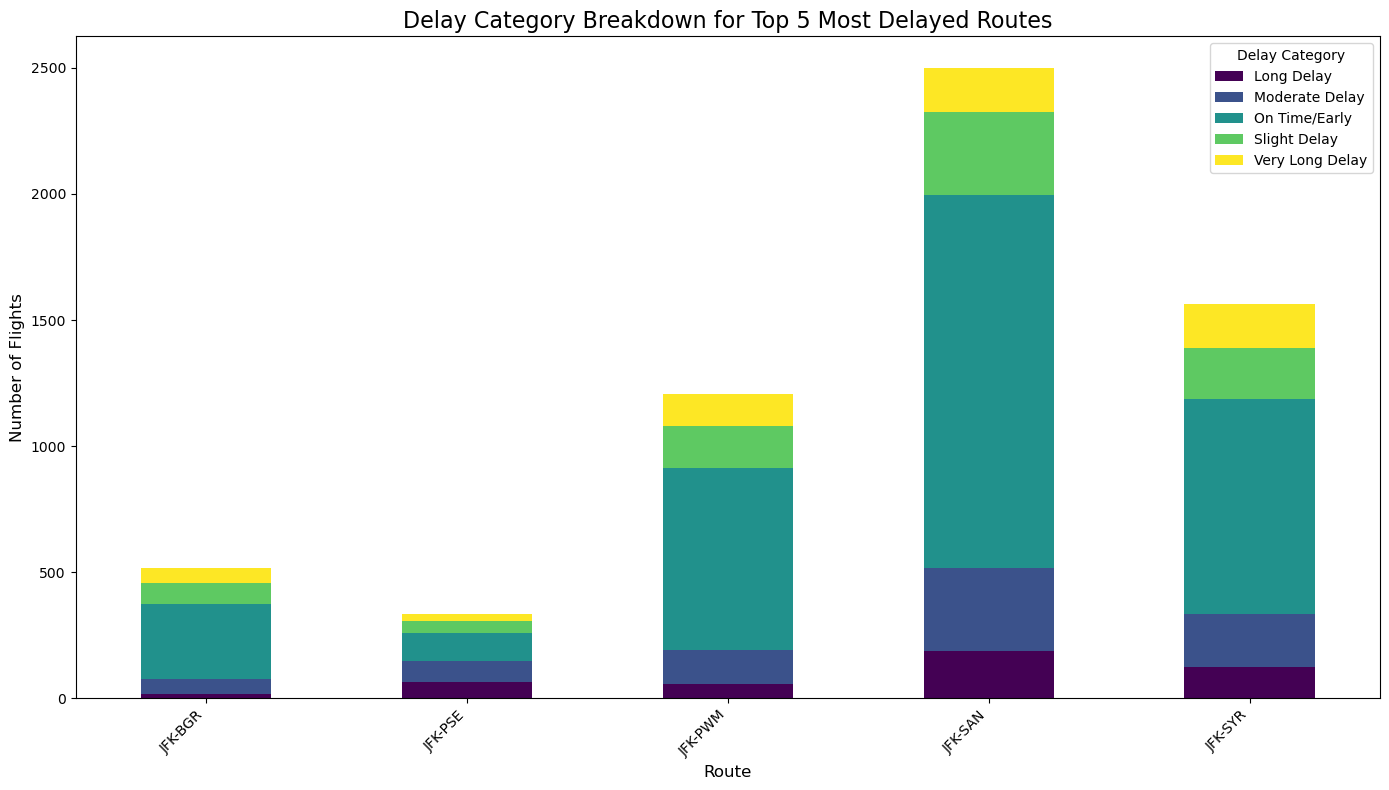

In [120]:
# 3. Delay Category Breakdown per Route for worst 5 routes

# Identify the top 5 most delayed routes
top_routes = df.groupby('route')['arr_delay'].mean().nlargest(5).index

# Filter the dataframe for these top routes
df_top_routes = df[df['route'].isin(top_routes)]

# Group by route and delay category, then count flights
route_category_counts = df_top_routes.groupby(['route', 'arr_delay_category']).size().unstack(fill_value=0)

route_category_counts.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='viridis')
plt.title('Delay Category Breakdown for Top 5 Most Delayed Routes', fontsize=16)
plt.xlabel('Route', fontsize=12)
plt.ylabel('Number of Flights', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Delay Category')
plt.tight_layout()
plt.show()

This stacked bar chart, "Delay Category Breakdown for Top 5 Most Delayed Routes," breaks down the total number of flights on five specific routes by their delay severity.

JFK-SAN has the highest overall number of flights among the top delayed routes and a very large proportion of 'Very Long Delay' flights (the yellow segment), indicating severe, chronic delay issues.

The majority of flights on all these routes fall into the 'Moderate Delay' (teal) and 'Slight Delay' (green) categories.

The routes JFK-BGR and JFK-PSE have a relatively small number of flights overall but still show a significant proportion of 'Very Long Delay' flights, suggesting that while less frequent, the delays on these routes are often very severe.

The chart confirms that the high average delays seen in the "Top 10 Most Delayed Routes" chart for routes like JFK-SAN and JFK-SFO are driven by a high number of flights experiencing long to very long delays.

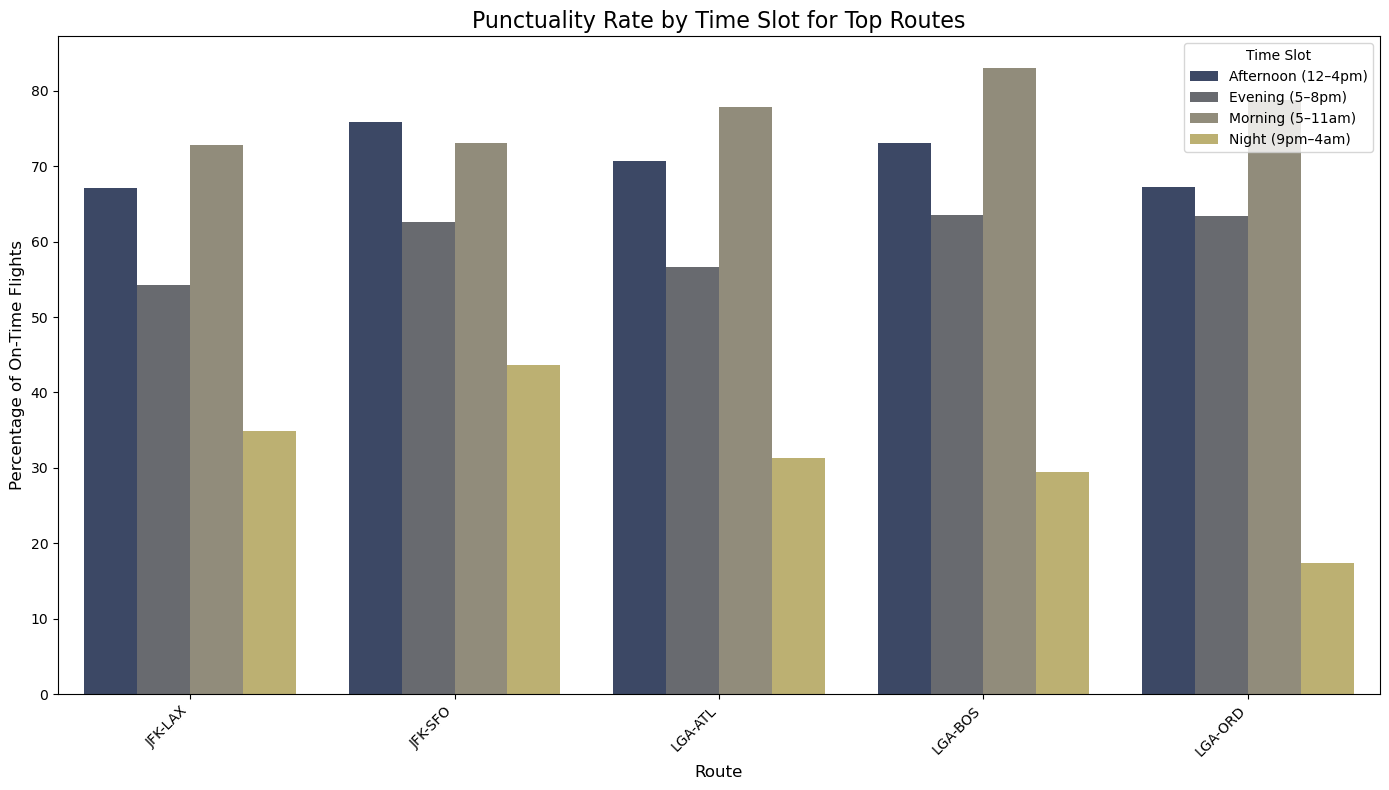

In [122]:
# 4.  Punctuality Rate by Time Slot and Route 
# Define 'on-time' flights
df['is_on_time'] = (df['arr_delay'] <= 0).astype(int)

# Identify top routes
top_routes = df.groupby('route')['arr_delay'].count().nlargest(5).index

# Filter for top routes
df_top_routes = df[df['route'].isin(top_routes)]

# Calculate on-time percentage for each route and time slot
punctuality_df = df_top_routes.groupby(['route', 'time_slot'])['is_on_time'].mean().mul(100).reset_index()

plt.figure(figsize=(14, 8))
sns.barplot(data=punctuality_df, x='route', y='is_on_time', hue='time_slot', palette='cividis')
plt.title('Punctuality Rate by Time Slot for Top Routes', fontsize=16)
plt.xlabel('Route', fontsize=12)
plt.ylabel('Percentage of On-Time Flights', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Time Slot')
plt.tight_layout()
plt.show()

The "Punctuality Rate by Time Slot for Top Routes" chart compares the percentage of on-time flights for different time slots across five major routes.

On all routes, flights in the Morning (5-11 am) time slot consistently have the highest on-time percentage, often exceeding 70% or even 80%. This suggests that early flights are the most reliable.

Night (9 pm-4 am) flights show the lowest punctuality rates on all routes, with some dropping below 20%. This highlights a significant drop in performance for late-night travel.

The Afternoon (12-4 pm) and Evening (5-8 pm) time slots show moderate performance, generally falling between the high punctuality of morning flights and the low punctuality of night flights.

The JFK-SFO route has a particularly low night-time punctuality rate, while LGA-BOS and LGA-ORD perform comparatively well in the evening.